# SILVA IFNO for Heterogeneous Materials

This lab derives the layer-independent Fourier residual increment, trains a
compact coefficient-to-displacement operator, compares shared depths, and maps
the implementation to displacement/damage studies. The mechanism follows IFNO
[[61]](https://jseluis.github.io/silva-networks/paper/references/#ref-61) and remains a configurable SILVA field point.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[31]](https://jseluis.github.io/silva-networks/paper/references/#ref-31), [[32]](https://jseluis.github.io/silva-networks/paper/references/#ref-32), [[61]](https://jseluis.github.io/silva-networks/paper/references/#ref-61). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from silva_networks import SILVAIFNO, make_ifno_material_dataset

## 1. Material Operator Contract

The input field may concatenate coordinates $x$, material descriptor $b(x)$,
body force, padded Dirichlet values, and padded traction. IFNO lifts it to
$h_0=P[f]$ and reuses

$$
h_{l+1}=h_l+\Delta t\,\sigma\left(
Wh_l+\mathcal F^{-1}(R_\theta\mathcal F[h_l])+c\right).
$$

For the compact heterogeneous bar, equilibrium gives
$du/dx=T/E(x)$ and $u(0)=0$, so cumulative quadrature supplies an exact target.

In [3]:
data = make_ifno_material_dataset(samples=16, height=8, width=24, seed=30)
assert data.inputs.shape == (16, 4, 8, 24)
print("input/target:", data.inputs.shape, data.target.shape)
print("modulus range:", float(data.modulus.min()), float(data.modulus.max()))

input/target: torch.Size([16, 4, 8, 24]) torch.Size([16, 1, 8, 24])
modulus range: 0.777289867401123 2.095899820327759


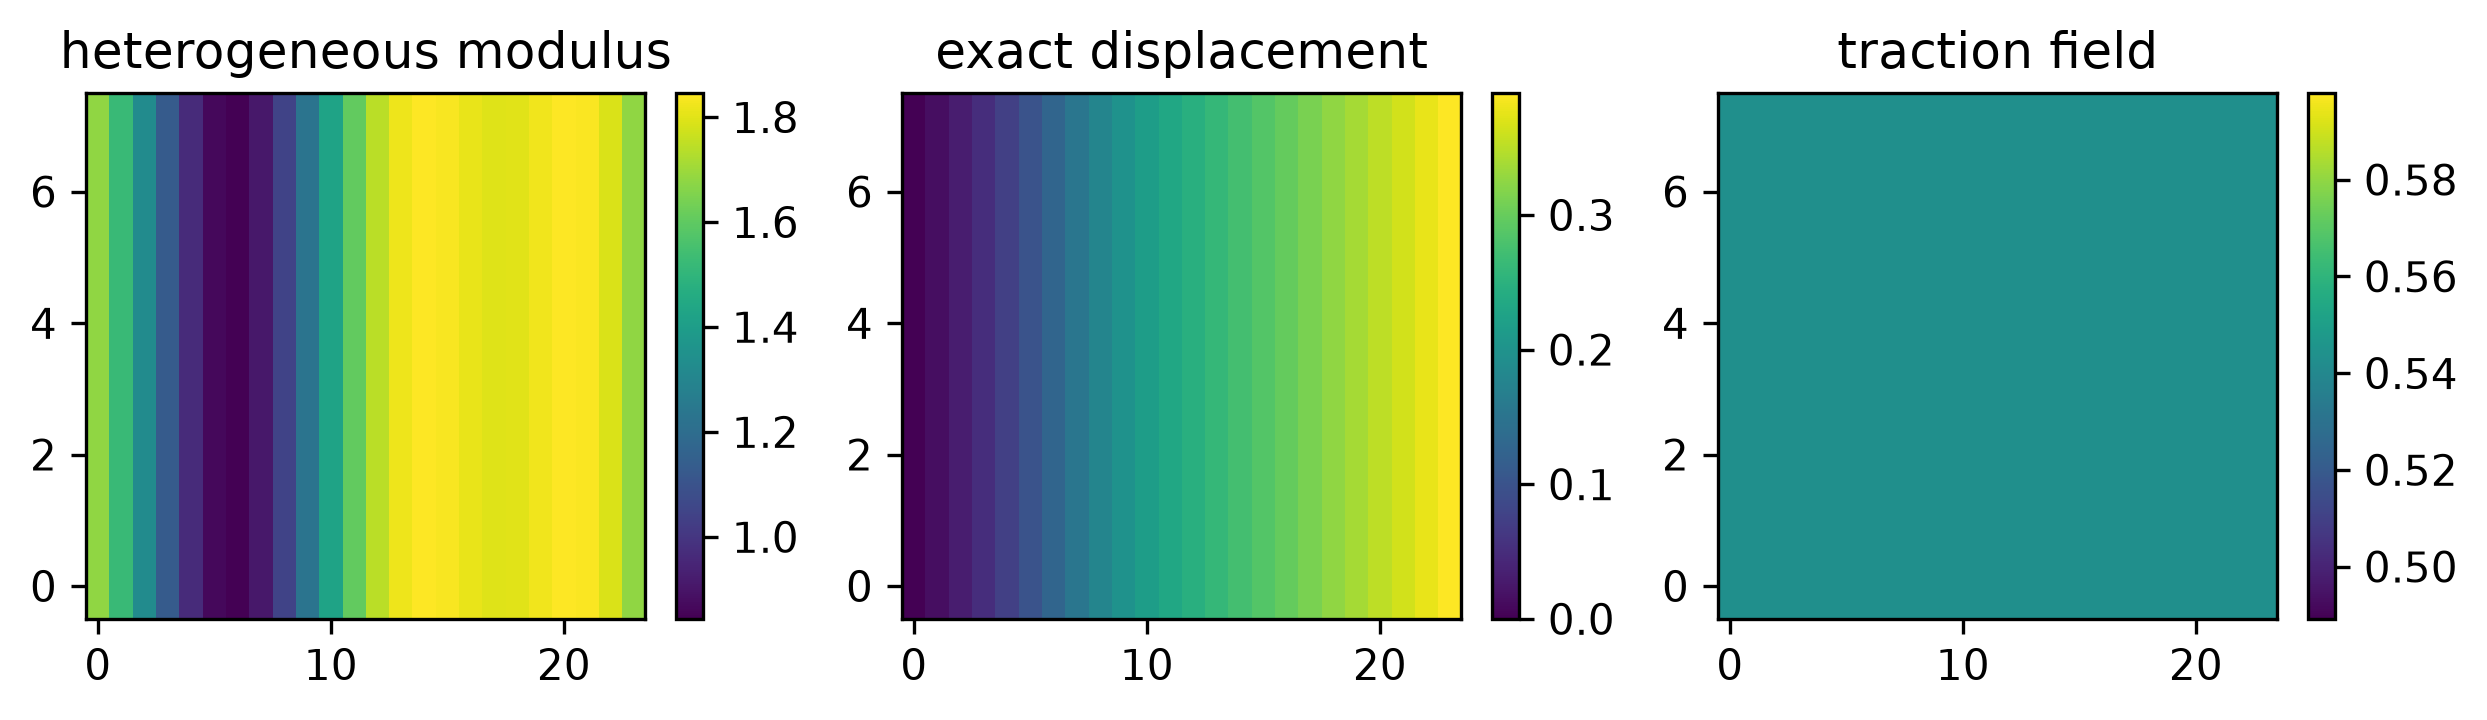

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(8.4, 2.5))
for axis, values, title in zip(
    axes,
    [data.modulus[0, 0], data.target[0, 0], data.inputs[0, 3]],
    ["heterogeneous modulus", "exact displacement", "traction field"],
):
    image = axis.imshow(values, aspect="auto", origin="lower", cmap="viridis")
    axis.set_title(title)
    figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

## 2. Tied Depth and Deep Limit

The same increment module is called at every depth. Dividing by $\Delta t$
shows a nonlocal evolution equation. The `unrolled` mode matches finite shared
depth. The `equilibrium` mode solves for zero increment and is intended for
deep-limit studies where that root is well posed.

In [5]:
model = SILVAIFNO(
    in_channels=4,
    state_channels=12,
    out_channels=1,
    depth=6,
    step_size=0.08,
    modes_height=3,
    modes_width=6,
)
result = model(data.inputs[:2], return_result=True)
assert len(result.increment_norms) == 6
print("shared increment object:", id(model.increment))
print("increment norms:", [round(value, 3) for value in result.increment_norms])

shared increment object: 4923655440
increment norms: [28.634, 29.093, 29.597, 30.145, 30.736, 31.37]


## 3. Compact Coefficient-to-Displacement Training

This task validates the data route, spectral/local gradient path, shared-depth
reuse, and physical readout. It is not a heterogeneous-material benchmark.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=8e-3)
losses = []
for _ in range(45):
    optimizer.zero_grad()
    prediction = model(data.inputs)
    loss = torch.nn.functional.mse_loss(prediction, data.target)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

with torch.no_grad():
    prediction = model(data.inputs[:1])
relative = torch.linalg.vector_norm(prediction - data.target[:1])
relative = relative / torch.linalg.vector_norm(data.target[:1])
print("initial/final loss:", losses[0], losses[-1])
print("sample relative L2:", float(relative))

initial/final loss: 0.36228978633880615 0.0045327250845730305
sample relative L2: 0.1704639494419098


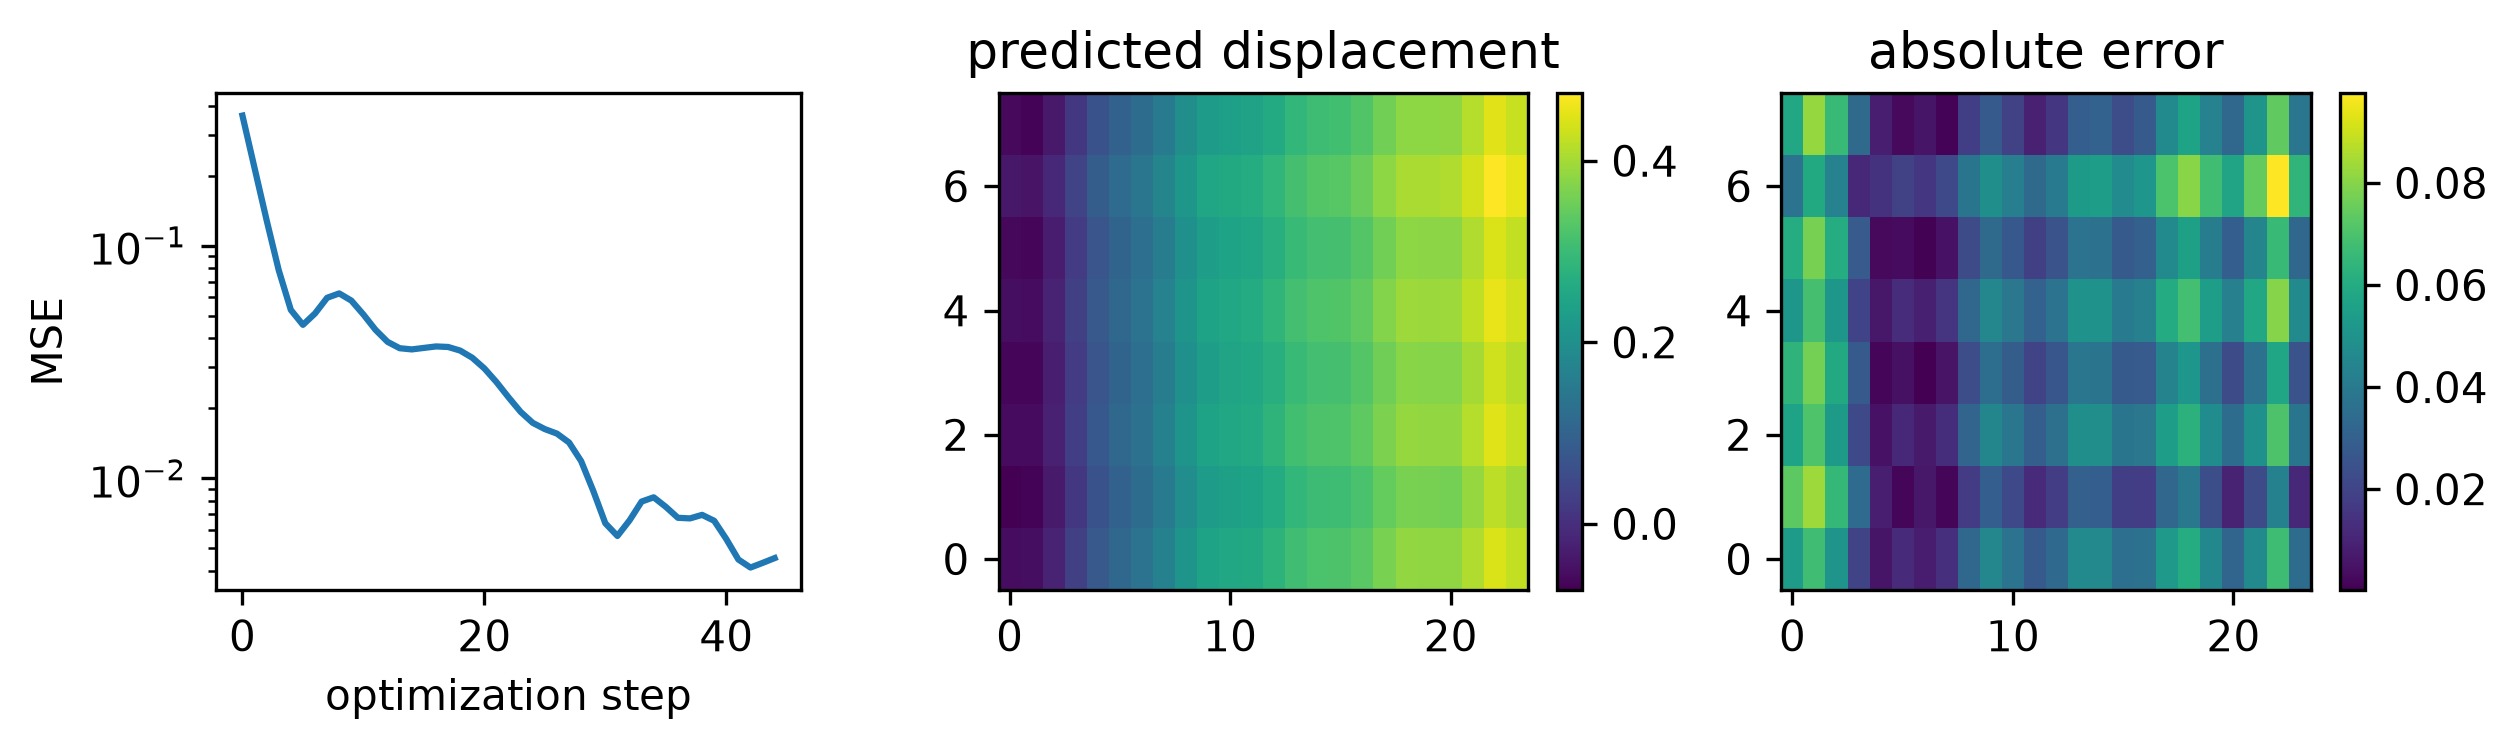

In [7]:
figure, axes = plt.subplots(1, 3, figsize=(8.5, 2.6))
axes[0].semilogy(losses)
axes[0].set(xlabel="optimization step", ylabel="MSE")
for axis, values, title in zip(
    axes[1:],
    [prediction[0, 0], (prediction[0, 0] - data.target[0, 0]).abs()],
    ["predicted displacement", "absolute error"],
):
    image = axis.imshow(values, aspect="auto", origin="lower", cmap="viridis")
    axis.set_title(title)
    figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

## 4. Displacement, Damage, and Source-Scale Runs

Use `out_channels=2` for scalar displacement plus damage, or the physical
spatial dimension plus damage for vector displacement. A custom readout can
leave displacement unbounded and apply a sigmoid only to damage. Reproduce a
source task by matching its simulated/experimental fields, boundary padding,
normalization, Fourier modes, shared depth, shallow-to-deep initialization,
optimizer, split, and relative field metrics. Storage follows
`samples x channels x H x W x dtype_bytes`; record each source archive and
preprocessing revision because material datasets vary by task.

## Source Data and Full Experiment Preflight

The source material simulations and DIC measurements [[61]](https://jseluis.github.io/silva-networks/paper/references/#ref-61) are not one redistributable archive. Start with 64-256 declared fields at 32-by-32, then restore the chosen constitutive task, units, grid, modes, shared depth, split, and normalization.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [8]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_ifno')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://arxiv.org/abs/2203.08205
access:
 - The cited article describes simulation and experimental DIC tasks but does not identify one public benchmark archive.
 - Use an openly released task when available, regenerate the stated constitutive simulations, or provide licensed DIC tensors; never substitute a different task silently.
storage:
 - Dense field bytes = samples * (input channels + output channels) * height * width * bytes per element.
 - Add simulator outputs, normalization statistics, optimizer state, and checkpoints; use sharded tensors for multi-resolution fields.
source-scale steps:
 1. Choose exactly one source material task and reproduce its simulator or DIC preprocessing, units, split, and normalization.
 2. Map coordinates, material descriptors, loads, and boundary values to input channels and use the shared SILVAIFNO increment at the reported depth and modes.
 3. Evaluate displacement or damage error, depth stability, and resolution transfer before a

## From 30 Silva Ifno Materials to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | a sampled solution field on a grid or mesh |
| Condition | coefficient, forcing, boundary, and coordinate fields |
| Repeated computation | a tied local/spectral/operator field with source reinjection |
| Required invariants | spatial shape, boundary conditions, and resolution semantics |
| Replaceable components | lifting map, spectral/local operator, physics field, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Tied Material Increment

```python
model = SILVAIFNO(
    in_channels=input_fields,
    state_channels=width,
    out_channels=material_fields,
    lift=my_material_lift,
    increment=my_tied_fourier_increment,
    readout=my_displacement_damage_head,
    depth=implicit_depth,
    step_size=delta_t,
)
```

The increment preserves spatial resolution and is reused at every depth. A
full material experiment can expose displacement, strain, stress, and damage
heads while retaining the same tied spectral/local transition and boundary
channels.


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**solution error, PDE residual, boundary error, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **resolution, retained modes, channels, domain size, and dataset size**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '30_silva_ifno_materials.ipynb',
    "state": 'a sampled solution field on a grid or mesh',
    "condition": 'coefficient, forcing, boundary, and coordinate fields',
    "transition": 'a tied local/spectral/operator field with source reinjection',
    "invariants": 'spatial shape, boundary conditions, and resolution semantics',
    "compact_metric": 'solution error, PDE residual, boundary error, and fixed-point residual',
    "scale_axis": 'resolution, retained modes, channels, domain size, and dataset size',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '30_silva_ifno_materials.ipynb',
 'state': 'a sampled solution field on a grid or mesh',
 'condition': 'coefficient, forcing, boundary, and coordinate fields',
 'transition': 'a tied local/spectral/operator field with source reinjection',
 'invariants': 'spatial shape, boundary conditions, and resolution semantics',
 'compact_metric': 'solution error, PDE residual, boundary error, and fixed-point residual',
 'scale_axis': 'resolution, retained modes, channels, domain size, and dataset size'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **operator feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **a sampled solution field on a grid or mesh**, and its repeated map,
**a tied local/spectral/operator field with source reinjection**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('operator feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


operator feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


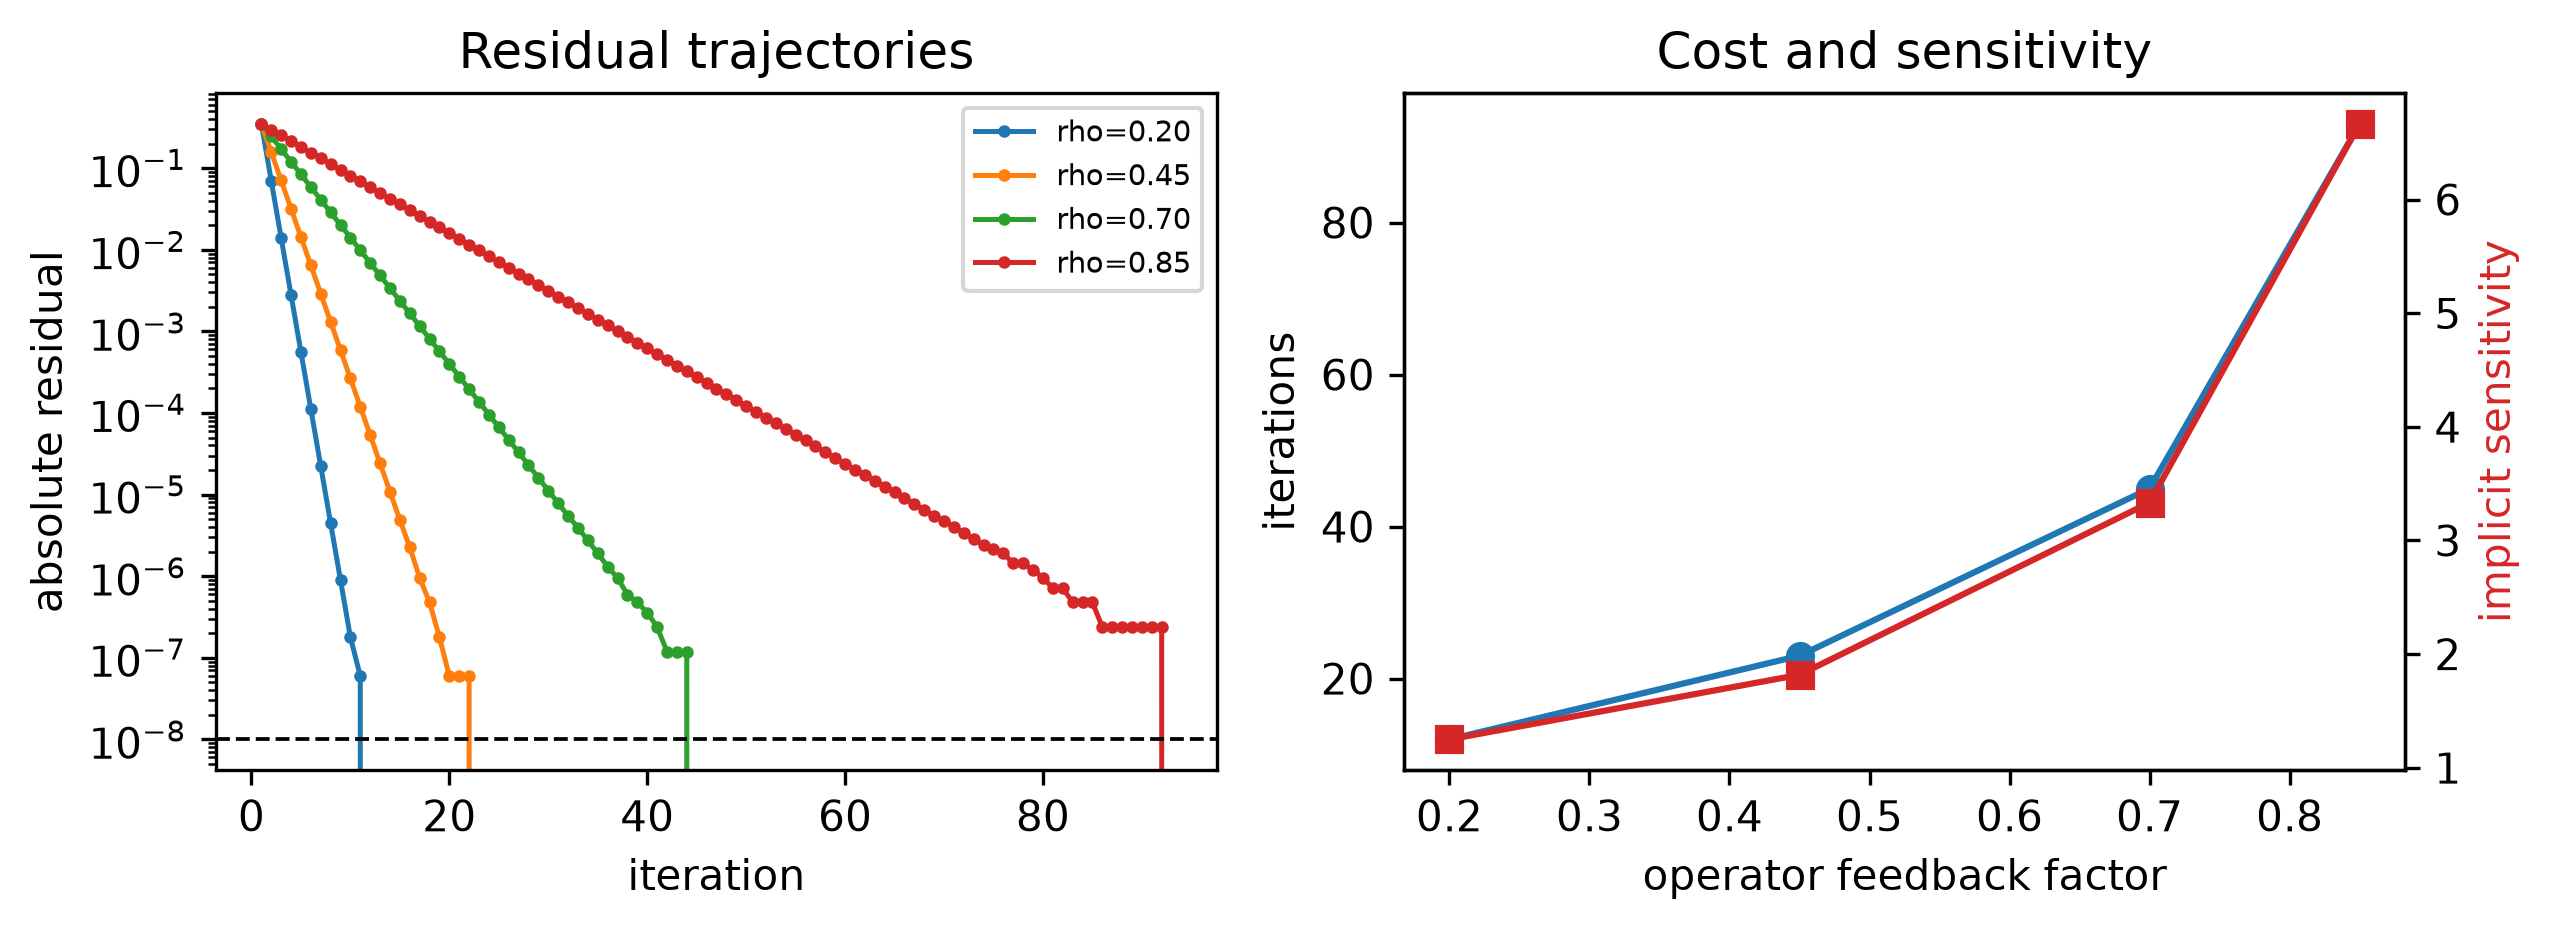

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('operator feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the operator feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | solution error, PDE residual, boundary error, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | spatial shape, boundary conditions, and resolution semantics |
| Scale sweep | Change one of resolution, retained modes, channels, domain size, and dataset size at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is the tied Fourier material update derived? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#ifno-material-operator) |
| Which tied increments and material datasets are public? | [Emerging Data API](https://jseluis.github.io/silva-networks/api/emerging_data/) |
| How do Fourier operators fit the SILVA point contract? | [Neural Operators, ODEs, PDEs, and SILVA](https://jseluis.github.io/silva-networks/learn/neural-operators-ode-pde/) |
